In [2]:
!pip install opendatasets --quiet
import opendatasets as od
od.download("https://www.kaggle.com/datasets/mssmartypants/rice-type-classification")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/mssmartypants/rice-type-classification


100%|██████████| 888k/888k [00:00<00:00, 716MB/s]

In [36]:
import torch
import torch.nn as nn
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
from torchsummary import summary
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
device = 'mps' if torch.mps.is_available() else 'cpu'
device

'mps'

In [97]:
df = pd.read_csv('riceClassification.csv')
df.head(10)
df.dropna(inplace=True)
df.drop(['id'], axis=1,inplace=True)
df['Class'].unique()
df['Class'].value_counts()
original_df = df.copy()

In [38]:
for column in df.columns:
    df[column] = df[column]/df[column].abs().max()

In [39]:
X = np.array(df.iloc[:,:-1])
Y = np.array(df.iloc[:,-1])

In [74]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
X_val, X_test, Y_val, Y_test = train_test_split(X_test, Y_test, test_size=0.5)

In [75]:
class dataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32).to(device)
        self.Y = torch.tensor(Y, dtype=torch.float32).to(device)

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, index):
        return self.X[index], self.Y[index]

In [76]:
training_data = dataset(X_train, Y_train)
validation_data = dataset(X_val, Y_val)
testing_data = dataset(X_test, Y_test)

In [77]:
train_dataloader = DataLoader(training_data, batch_size=32, shuffle=True)
test_dataloader = DataLoader(testing_data, batch_size=32, shuffle=False)
validation_dataloader = DataLoader(validation_data, batch_size=32, shuffle=True)

In [78]:
class MyModel(nn.Module):
    def __init__(self):
        super(MyModel, self).__init__()
        self.input_layer = nn.Linear(X.shape[1], 15)
        self.linear = nn.Linear(15, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.input_layer(x)
        x = self.linear(x)
        x = self.sigmoid(x)
        return x
model = MyModel().to(device)

In [79]:
model.cpu()
summary(model, (X.shape[1],))
model.to('mps')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                   [-1, 15]             165
            Linear-2                    [-1, 1]              16
           Sigmoid-3                    [-1, 1]               0
Total params: 181
Trainable params: 181
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00
----------------------------------------------------------------


MyModel(
  (input_layer): Linear(in_features=10, out_features=15, bias=True)
  (linear): Linear(in_features=15, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [80]:
criterion = nn.BCELoss()
optimizer = Adam(model.parameters(), lr = 1e-4)

In [81]:
total_loss_train_plot = []
total_loss_validation_plot = []
total_acc_train_plot = []
total_acc_validation_plot = []

EPOCHS = 20
for epoch in range(EPOCHS):
    total_acc_train = 0
    total_loss_train = 0
    total_acc_val = 0
    total_loss_val = 0

    for data in train_dataloader:
        inputs, labels = data
        
        prediction = model(inputs).squeeze(1)
        batch_loss = criterion(prediction, labels)
        total_loss_train += batch_loss.item()
        acc = ((prediction).round() == labels).sum().item()
        total_acc_train += acc

        batch_loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    with torch.no_grad():
        for data in validation_dataloader:
            inputs, labels = data
            prediction = model(inputs).squeeze(1)
            batch_loss = criterion(prediction, labels)
            
            total_loss_val += batch_loss.item()
            acc = ((prediction).round() == labels).sum().item()
            total_acc_val += acc
    
    total_loss_train_plot.append(round(total_loss_train/1000, 4))
    total_loss_validation_plot.append(round(total_loss_val/1000, 4))

    total_acc_train_plot.append(round(total_acc_train/training_data.__len__() * 100, 4))
    total_acc_validation_plot.append(round(total_acc_val/validation_data.__len__() * 100, 4))

    print(f'''Epoch no. {epoch+1} Train Loss: {round(total_loss_train/1000, 4)} Train Accuracy {round(total_acc_train/training_data.__len__() * 100, 4)}
          Validation Loss: {round(total_loss_val/1000, 4)} Validation Accuracy {round(total_acc_val/validation_data.__len__() * 100, 4)}''')
    print('='*25)

Epoch no. 1 Train Loss: 0.3049 Train Accuracy 55.3891
          Validation Loss: 0.0377 Validation Accuracy 54.5655
Epoch no. 2 Train Loss: 0.2954 Train Accuracy 65.0536
          Validation Loss: 0.0364 Validation Accuracy 65.4015
Epoch no. 3 Train Loss: 0.2847 Train Accuracy 81.8944
          Validation Loss: 0.0349 Validation Accuracy 91.3091
Epoch no. 4 Train Loss: 0.2719 Train Accuracy 92.9406
          Validation Loss: 0.0332 Validation Accuracy 92.7943
Epoch no. 5 Train Loss: 0.2568 Train Accuracy 94.0198
          Validation Loss: 0.0311 Validation Accuracy 97.4697
Epoch no. 6 Train Loss: 0.2397 Train Accuracy 96.4119
          Validation Loss: 0.0289 Validation Accuracy 98.0198
Epoch no. 7 Train Loss: 0.2213 Train Accuracy 97.113
          Validation Loss: 0.0265 Validation Accuracy 98.0748
Epoch no. 8 Train Loss: 0.2022 Train Accuracy 97.5048
          Validation Loss: 0.0241 Validation Accuracy 97.6898
Epoch no. 9 Train Loss: 0.1833 Train Accuracy 97.6423
          Validatio

In [82]:
with torch.no_grad():
    total_loss_test = 0
    total_acc_test = 0
    for data in test_dataloader:
        inputs, labels = data
        prediction = model(inputs).squeeze(1)
        batch_loss_test = criterion(prediction, labels).item()
        total_loss_test += batch_loss_test
        acc = ((prediction).round() == labels).sum().item()
        total_acc_test += acc
print(f'''Accuracy: {round(total_acc_test/testing_data.__len__() * 100, 4)}''')

Accuracy: 98.6806


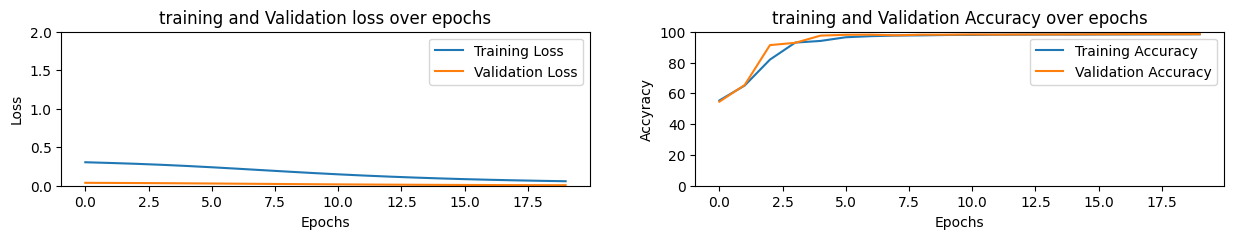

In [88]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(15,2))
axs[0].plot(total_loss_train_plot, label = 'Training Loss')
axs[0].plot(total_loss_validation_plot, label = 'Validation Loss')
axs[0].set_title("training and Validation loss over epochs")
axs[0].set_xlabel("Epochs")
axs[0].set_ylabel("Loss")
axs[0].set_ylim([0,2])
axs[0].legend()

axs[1].plot(total_acc_train_plot, label = 'Training Accuracy')
axs[1].plot(total_acc_validation_plot, label = 'Validation Accuracy')
axs[1].set_title("training and Validation Accuracy over epochs")
axs[1].set_xlabel("Epochs")
axs[1].set_ylabel("Accyracy")
axs[1].set_ylim([0,100])
axs[1].legend()

In [102]:
area = 2353/original_df['Area'].abs().max()
MajorAxisLength = 81/original_df['MajorAxisLength'].abs().max()
MinorAxisLength = 42/original_df['MinorAxisLength'].abs().max()
Eccentricity = 32/original_df['Eccentricity'].abs().max()
ConvexArea = 12/original_df['ConvexArea'].abs().max()
EquivDiameter = 33/original_df['EquivDiameter'].abs().max()
Perimeter = 982/original_df['Perimeter'].abs().max()
Extent = 98/original_df['Extent'].abs().max()
Roundness = 927/original_df['Roundness'].abs().max()
AspectRation = 24/original_df['AspectRation'].abs().max()
model(torch.tensor([area, MajorAxisLength, MinorAxisLength, Eccentricity, ConvexArea, EquivDiameter, Perimeter, Extent,Roundness,AspectRation], dtype=torch.float32).to(device))

tensor([0.], device='mps:0', grad_fn=<SigmoidBackward0>)

In [98]:
original_df.columns

Index(['Area', 'MajorAxisLength', 'MinorAxisLength', 'Eccentricity',
       'ConvexArea', 'EquivDiameter', 'Extent', 'Perimeter', 'Roundness',
       'AspectRation', 'Class'],
      dtype='object')